In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv


In [2]:
df=pd.read_csv('/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv')

# Business Objective: Fraud Detection using Machine Learning

#### 🔹 Problem Statement
Financial fraud is a growing concern in the banking and payments industry. Fraudulent transactions lead to **significant financial losses** and impact both **businesses and customers**. Traditional rule-based fraud detection methods **fail to scale effectively**, leading to **high false positive rates** and **missed fraudulent activities**.

Our goal is to develop an **automated fraud detection system** using **Machine Learning (XGBoost)** that can:  
✅ **Accurately detect fraudulent transactions in real-time.**  
✅ **Minimize financial losses by reducing missed fraud cases.**  
✅ **Reduce false positives to avoid unnecessary transaction blocks.**  

---

###  Business Impact
A well-optimized fraud detection model will:  
✔ **Prevent financial losses** by flagging fraudulent transactions.  
✔ **Improve customer experience** by reducing false fraud alerts.  
✔ **Enhance security & compliance** with regulatory requirements.  

💡 **A strong fraud detection system is not just about catching fraud—it’s about minimizing risk while maintaining a seamless transaction experience for legitimate users.**  

---

###  Key Performance Metrics
To measure the effectiveness of our fraud detection model, we focus on the following metrics:

- **🔹 Recall (Priority Metric)** – Detect as many fraudulent transactions as possible.  
- **🔹 Precision** – Ensure flagged transactions are actually fraudulent.  
- **🔹 F1-Score** – Balance between Precision & Recall.  
- **🔹 Accuracy** – Overall correctness of predictions.  


In [3]:
df.shape

(6362620, 11)

In [4]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


# 1. Data Preprocessing

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
6362615    False
6362616    False
6362617    False
6362618    False
6362619    False
Length: 6362620, dtype: bool

In [8]:
df.drop(columns=['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], inplace= True)
df_cleaned=df

In [9]:
unique_transaction_types=df_cleaned["type"].unique()
print(unique_transaction_types)

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


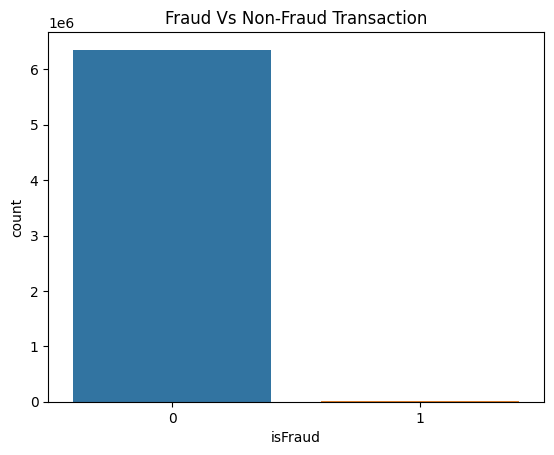

In [10]:
# Check Class Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="isFraud",data=df_cleaned)
plt.title("Fraud Vs Non-Fraud Transaction")
plt.show()

In [11]:
# Check Fraud Rates in Different Transaction Types

fraud_rates=df_cleaned.groupby("type")["isFraud"].mean()
print(fraud_rates)

type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64


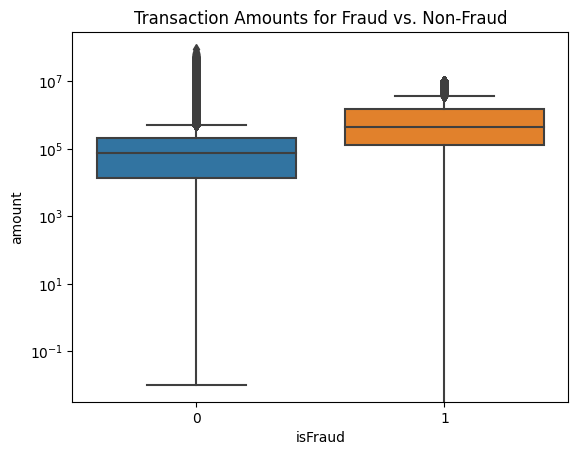

In [12]:
# Analyze Transaction Amounts

sns.boxplot(x="isFraud", y="amount", data=df_cleaned)
plt.title("Transaction Amounts for Fraud vs. Non-Fraud")
plt.yscale("log")  # Log scale helps visualize high-value transactions
plt.show()

In [13]:
df_cleaned.describe()

,step,amount,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,1.000000e+00,1.000000e+00


In [14]:
# Step 1: Convert "type" column (categorical) to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_cleaned['type'] = encoder.fit_transform(df_cleaned['type'])

In [15]:
# Convert integer columns to smaller data types
df_cleaned['step'] = df_cleaned['step'].astype('int32')
df_cleaned['isFraud'] = df_cleaned['isFraud'].astype('int8')
df_cleaned['isFlaggedFraud'] = df_cleaned['isFlaggedFraud'].astype('int8')

# Convert float columns to float32
df_cleaned['amount'] = df_cleaned['amount'].astype('float32')

### Above data type optimization is crucial for reducing memory usage and improving computational efficiency. 

In [16]:
# Check new data types and memory usage
print(df_cleaned.info())
print(f"Memory Usage After Optimization: {df_cleaned.memory_usage().sum() / 1024**2:.2f} MB")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int32  
 1   type            int64  
 2   amount          float32
 3   nameOrig        object 
 4   nameDest        object 
 5   isFraud         int8   
 6   isFlaggedFraud  int8   
dtypes: float32(1), int32(1), int64(1), int8(2), object(2)
memory usage: 206.3+ MB
None
Memory Usage After Optimization: 206.31 MB


# According to Visualization results, the data is imbalanced and we need to handle that

In [17]:
from imblearn.under_sampling import RandomUnderSampler

# Define features and target variable
X = df_cleaned.drop(columns=['isFraud'])
y = df_cleaned['isFraud']

# Apply undersampling (Adjust ratio as needed)
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Verify new class distribution
print("Fraud Cases Before:\n", y.value_counts())
print("Fraud Cases After Undersampling:\n", pd.Series(y_resampled).value_counts())

Fraud Cases Before:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Cases After Undersampling:
 isFraud
0    82130
1     8213
Name: count, dtype: int64


# 2. Feature Engineering

In [18]:
correlation = df_cleaned[['isFraud', 'isFlaggedFraud']].corr()
print(correlation)

                 isFraud  isFlaggedFraud
isFraud         1.000000        0.044109
isFlaggedFraud  0.044109        1.000000


# Interpretation of Correlation Between `isFraud` and `isFlaggedFraud`

The correlation between `isFraud` and `isFlaggedFraud` is **0.044**, which is **very low**.

---

### **1️⃣ Flagged transactions (`isFlaggedFraud`) have little to no relationship with actual fraud (`isFraud`).**
- Just because a transaction is flagged **does not mean it is fraud**.
- Likewise, most fraudulent transactions **are not flagged**.

---

### **2️⃣ `isFlaggedFraud` is NOT a useful feature for fraud detection.**
- Since the correlation is near **zero**, it won’t help predict fraud.
- **We should drop `isFlaggedFraud` from the model.**


In [19]:
fraud_not_flagged = df_cleaned[(df_cleaned['isFraud'] == 1) & (df_cleaned['isFlaggedFraud'] == 0)]
print(f"Number of fraud cases NOT flagged: {len(fraud_not_flagged)}")

Number of fraud cases NOT flagged: 8197


In [20]:
df_cleaned.drop(columns=['isFlaggedFraud'], inplace=True)

In [21]:
fraud_not_flagged.describe()

,step,type,amount,isFraud,isFlaggedFraud
count,8197.000000,8197.000000,8.197000e+03,8197.0,8197.0
mean,368.083689,2.493595,1.461343e+06,1.0,0.0
std,216.330669,1.500078,2.397046e+06,0.0,0.0
min,1.000000,1.000000,0.000000e+00,1.0,0.0
25%,181.000000,1.000000,1.268486e+05,1.0,0.0
50%,367.000000,1.000000,4.389834e+05,1.0,0.0
75%,558.000000,4.000000,1.504870e+06,1.0,0.0
max,743.000000,4.000000,1.000000e+07,1.0,0.0


## Implement New Fraud Indicators
## (a) Detect suspicious high-value transactions:

In [22]:
df_cleaned['high_amount'] = (df_cleaned['amount'] > 200000).astype(int)

## (b) Compare amount to user’s normal transaction range:


In [23]:
df_cleaned['orig_avg_amount'] = df_cleaned.groupby('nameOrig')['amount'].transform('mean')

In [24]:
df_cleaned['suspicious_amount'] = (df_cleaned['amount'] > df_cleaned['orig_avg_amount'] * 5).astype(int)

In [25]:
df_cleaned.columns

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'high_amount', 'orig_avg_amount', 'suspicious_amount'],
      dtype='object')

In [26]:
# 1. Number of transactions per origin and destination
df_cleaned['orig_tx_count'] = df_cleaned.groupby('nameOrig')['step'].transform('count')
df_cleaned['dest_tx_count'] = df_cleaned.groupby('nameDest')['step'].transform('count')

# 2. Standard deviation of transaction amounts
df_cleaned['orig_tx_std'] = df_cleaned.groupby('nameOrig')['amount'].transform('std').fillna(0)
df_cleaned['dest_tx_std'] = df_cleaned.groupby('nameDest')['amount'].transform('std').fillna(0)

# 3. Transaction type flags
df_cleaned['is_transfer'] = (df_cleaned['type'] == 'TRANSFER').astype(int)
df_cleaned['is_cashout'] = (df_cleaned['type'] == 'CASH_OUT').astype(int)

# 4. Extract hour of the day from 'step'
df_cleaned['hour_of_day'] = df_cleaned['step'] % 24

# 5. Binary flag for merchant transactions
df_cleaned['is_merchant'] = df_cleaned['nameDest'].str.startswith('M').astype(int)

# Verify new features are added
print(df_cleaned.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'high_amount', 'orig_avg_amount', 'suspicious_amount', 'orig_tx_count',
       'dest_tx_count', 'orig_tx_std', 'dest_tx_std', 'is_transfer',
       'is_cashout', 'hour_of_day', 'is_merchant'],
      dtype='object')


In [27]:
df_cleaned.head()

,step,type,amount,nameOrig,nameDest,isFraud,high_amount,orig_avg_amount,suspicious_amount,orig_tx_count,dest_tx_count,orig_tx_std,dest_tx_std,is_transfer,is_cashout,hour_of_day,is_merchant
0,1,3,9839.639648,C1231006815,M1979787155,0,0,9839.639648,0,1,1,0.0,0.000000,0,0,1,1
1,1,3,1864.280029,C1666544295,M2044282225,0,0,1864.280029,0,1,1,0.0,0.000000,0,0,1,1
2,1,4,181.000000,C1305486145,C553264065,1,0,181.000000,0,1,44,0.0,252655.762725,0,0,1,0
3,1,1,181.000000,C840083671,C38997010,1,0,181.000000,0,1,41,0.0,878990.449916,0,0,1,0
4,1,3,11668.139648,C2048537720,M1230701703,0,0,11668.139648,0,1,1,0.0,0.000000,0,0,1,1


In [28]:
df_cleaned.drop(columns=['oldbalanceOrg', 'newbalanceOrg', 'oldbalanceDest', 'newbalanceDest'], inplace=True, errors='ignore')

In [29]:
df_cleaned.columns

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'high_amount', 'orig_avg_amount', 'suspicious_amount', 'orig_tx_count',
       'dest_tx_count', 'orig_tx_std', 'dest_tx_std', 'is_transfer',
       'is_cashout', 'hour_of_day', 'is_merchant'],
      dtype='object')

# 3. ML Modeling

In [30]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_cleaned.drop(columns=['isFraud'])  # Exclude target column
y = df_cleaned['isFraud']

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print("Training set:", y_train.value_counts())
print("Test set:", y_test.value_counts())

Training set: isFraud
0    65704
1     6570
Name: count, dtype: int64
Test set: isFraud
0    16426
1     1643
Name: count, dtype: int64


In [31]:
X_train = X_train.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
X_test = X_test.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

print(X_train.dtypes)

step                int32
type                int64
amount            float32
isFlaggedFraud       int8
dtype: object


# XGBoost

In [32]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [33]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [34]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=750,    # Number of boosting rounds (trees)
    learning_rate=0.3,   # Controls step size during training
    max_depth=7,         # Limits tree depth to prevent overfitting
    random_state=42
)

# Train the model using the CORRECT train set
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

In [35]:
y_pred_prob = xgb_model.predict_proba(X_test)[:,1]  # Get fraud probabilities
new_threshold = 0.15  # Adjust threshold
y_pred_adjusted = (y_pred_prob > new_threshold).astype(int)

In [36]:
# Model Accuracy
accuracy = accuracy_score(y_test, y_pred_adjusted)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted))

# Classification Report (Precision, Recall, F1-score)
print("Classification Report:\n", classification_report(y_test, y_pred_adjusted))

Accuracy: 0.9427
Confusion Matrix:
 [[15636   790]
 [  246  1397]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97     16426
           1       0.64      0.85      0.73      1643

    accuracy                           0.94     18069
   macro avg       0.81      0.90      0.85     18069
weighted avg       0.95      0.94      0.95     18069



# 3.1 Hyper Parameter Tuning

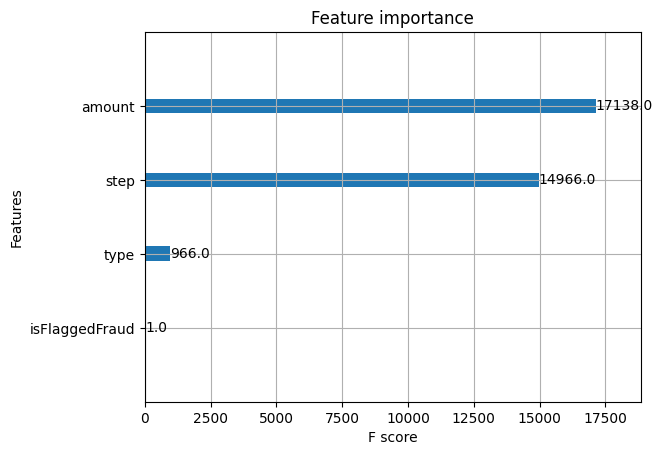

In [37]:
xgb.plot_importance(xgb_model)
plt.show()

In [38]:
# Removing isFlaggedFraud Feature

X_train = X_train.drop(columns=['isFlaggedFraud'], errors='ignore')
X_test = X_test.drop(columns=['isFlaggedFraud'], errors='ignore')

In [39]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=750,    # Number of boosting rounds (trees)
    learning_rate=0.3,   # Controls step size during training
    max_depth=7,         # Limits tree depth to prevent overfitting
    random_state=42
)

# Train the model using the CORRECT train set
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

In [40]:
y_pred_prob = xgb_model.predict_proba(X_test)[:,1]  # Get fraud probabilities
new_threshold = 0.15  # Adjust threshold
y_pred_adjusted = (y_pred_prob > new_threshold).astype(int)

In [41]:
# Model Accuracy
accuracy = accuracy_score(y_test, y_pred_adjusted)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted))

# Classification Report (Precision, Recall, F1-score)
print("Classification Report:\n", classification_report(y_test, y_pred_adjusted))

Accuracy: 0.9432
Confusion Matrix:
 [[15636   790]
 [  236  1407]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97     16426
           1       0.64      0.86      0.73      1643

    accuracy                           0.94     18069
   macro avg       0.81      0.90      0.85     18069
weighted avg       0.95      0.94      0.95     18069



### Final Model Evaluation Summary

After multiple fine-tuning steps, this is the **final version** of our fraud detection model.  
The following metrics provide insights into the model's performance and its ability to detect fraudulent transactions.

---

### **1️⃣ Accuracy**
- **📊 Accuracy: 94.32%**
- The model correctly classifies **94.32% of all transactions**.
- However, in fraud detection, **accuracy alone is not the best metric** because fraud cases are rare.

---

### **2️⃣ Confusion Matrix**
| Actual / Predicted | Non-Fraud (0) | Fraud (1) |
|--------------------|--------------|-----------|
| **Non-Fraud (0)** | 15,636 ✅ | 790 ❌ (False Positives) |
| **Fraud (1)** | 236 ❌ (False Negatives) | 1,407 ✅ |

#### **What This Means**
- **✅ True Positives (1,407)** → Correctly identified fraud cases.  
- **✅ True Negatives (15,636)** → Correctly classified legitimate transactions.  
- **⚠️ False Positives (790)** → Some legitimate transactions **wrongly flagged as fraud**.  
- **⚠️ False Negatives (236)** → **Missed fraud cases** (most critical issue).  

💡 **In fraud detection, minimizing False Negatives is a top priority.**

---

### **3️⃣ Precision, Recall, and F1-Score**
| Metric | Non-Fraud (0) | Fraud (1) | Overall |
|--------|--------------|-----------|---------|
| **Precision** | **0.99** | **0.64** | **0.81 (macro avg)** |
| **Recall** | **0.95** | **0.86** | **0.90 (macro avg)** |
| **F1-score** | **0.97** | **0.73** | **0.85 (macro avg)** |

- **🟢 Precision (Fraud: 0.64)** → Of all transactions flagged as fraud, **64% were actually fraud**.  
- **🟢 Recall (Fraud: 0.86)** → The model **successfully detected 86% of all real fraud cases**.  
- **🟢 F1-Score (Fraud: 0.73)** → A balance between **precision and recall**.

---

### **4️⃣ Why Recall is More Important in Fraud Detection**
💡 **In fraud detection, Recall is prioritized over Precision.**  

- **High Recall (86%)** means we catch most fraudulent transactions.
- **Low Recall would mean missing fraud cases**, which can result in **huge financial losses**.
- **False Positives (legitimate transactions flagged as fraud) are inconvenient but manageable.**  
  - A falsely flagged user **can verify their identity and continue transactions**.  
- **False Negatives (missed fraud cases) are much worse** because they allow fraud to happen undetected.  
  - **Example:** A scammer stealing money from multiple accounts would go unnoticed.  

✔ **For a bank or financial institution, missing fraud is far riskier than flagging an occasional legitimate transaction.**  

---

### **5️⃣ Key Takeaways**
✅ **High Recall (86%)** → The model effectively **catches fraud cases**.  
✅ **High Accuracy (94.32%)** → The model is well-optimized.  
⚠️ **Lower Precision (64%)** → Some legitimate transactions may be flagged, but this is acceptable.  
✔ **This is the final version of the model, and we are not tuning it further.**


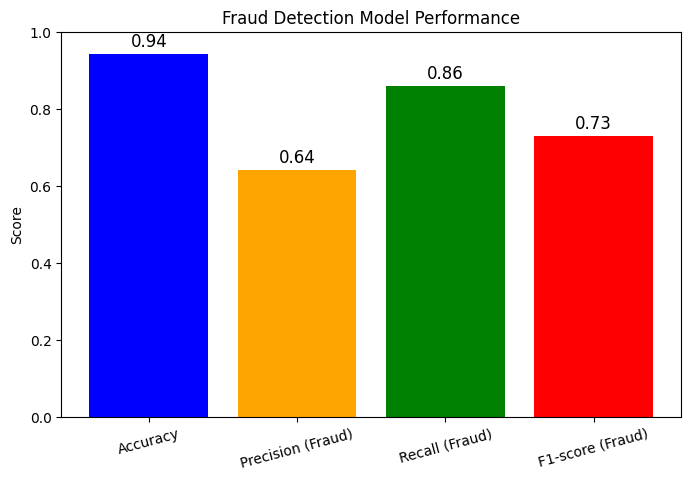

In [42]:
# Model performance metrics from the classification report
metrics = ["Accuracy", "Precision (Fraud)", "Recall (Fraud)", "F1-score (Fraud)"]
values = [0.9432, 0.64, 0.86, 0.73]  # Replace with actual values from your classification report

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])

# Labels & Title
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.ylabel("Score")
plt.title("Fraud Detection Model Performance")
plt.xticks(rotation=15)

# Show values on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)

# Show the plot
plt.show()

# 4. Conclusion

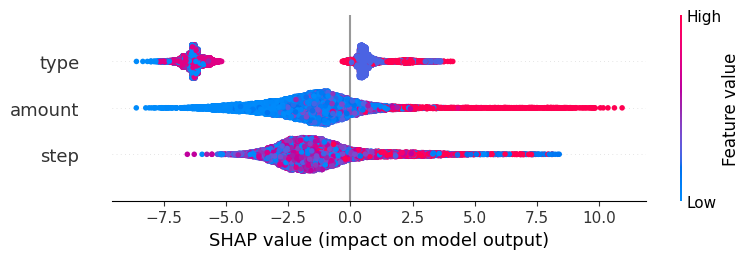

In [43]:
import shap
explainer = shap.Explainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

### Interpretation of SHAP Summary Plot

This **SHAP (SHapley Additive exPlanations) plot** helps us understand how each feature **impacts the model’s fraud prediction.** 

---

### **1️⃣ What Does This SHAP Plot Tell Us?**
#### ✅ **Feature Importance (Left to Right)**
- **`amount` (Most Important Feature)**
  - Higher transaction amounts (red points) **increase fraud risk** (positive SHAP values).
  - Smaller transactions (blue points) **decrease fraud risk** (negative SHAP values).
  
- **`step` (Time of Transaction)**
  - Certain time steps have **higher fraud risk**, but the effect is mixed.
  - Transactions happening in **some time windows may be more suspicious**.

- **`type` (Transaction Type)**
  - The transaction type has **a smaller but still notable impact**.
  - Some types (likely `"TRANSFER"` and `"CASH_OUT"`) are more associated with fraud.

---

### **2️⃣ Understanding the SHAP Value Colors**
- **🔴 Red → High Feature Value**  
  - **For `amount`**, larger values **increase fraud likelihood**.  
  - **For `step`**, transactions at certain times **increase fraud likelihood**.  

- **🔵 Blue → Low Feature Value**  
  - **For `amount`**, small transactions **decrease fraud likelihood**.  
  - **For `step`**, transactions at other time windows **reduce fraud suspicion**.  

- **SHAP Values (X-Axis)**  
  - **Negative SHAP Values (Left Side)** → Reduce likelihood of fraud.  
  - **Positive SHAP Values (Right Side)** → Increase likelihood of fraud.

---

### **3️⃣ Business Takeaways**
✅ **High-value transactions should be carefully monitored.**  
✅ **Fraudulent transactions tend to occur at specific time steps** (suggests organized fraud behavior).  
✅ **Certain transaction types (`type`) are linked to fraud but less than amount/time.**  
